In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
import boto3
import s3fs

In [3]:
import re

In [4]:
from scipy.signal import savgol_filter

In [5]:
SEGMENTS = ["P", "PQ", "QRS", "ST", "T"]  # ["P", "PQ", "QRS", "ST", "T", "TP"]
NLEADS = 12
bucket_out = "walkky-ml"
prefixes_out = [f"aruna-files/vqvae/segment_{segment_name}_nleads_{NLEADS}/training_outputs_{segment_name}.npz" for segment_name in SEGMENTS]

s3_client = boto3.client("s3")
s3_fs = s3fs.S3FileSystem()

Segment filename: aruna-files/vqvae/segment_P_nleads_12/training_outputs_P.npz
Segment name:  P
Available arrays: ['train_loss', 'train_recon_error', 'train_perplexity', 'val_loss', 'val_recon_error', 'val_perplexity', 'test_loss', 'test_recon_error', 'test_perplexity', 'vqvae_codebook']
Training VQ loss:  [0.02789014 0.03092775 0.02930044 0.02949818 0.02827212 0.02857217
 0.02731444 0.02698528 0.02698873 0.02664714 0.0261071  0.02561451
 0.02602576 0.02588829 0.02608656 0.02596559 0.02540353 0.02535259
 0.02537612 0.02552008 0.02499984 0.02554942 0.02550887 0.02550206
 0.02524722 0.02543488 0.02560118 0.02450217 0.02531725 0.02493937
 0.02488175 0.02455406 0.02501376 0.02524555 0.02510865 0.02556847
 0.02538605 0.02392127 0.02436251 0.02506002 0.02489548 0.02484542
 0.02544546 0.02395307 0.02403144 0.02460219 0.02427842 0.02483359
 0.02431476 0.0245933  0.02521343 0.02469678 0.02476597 0.02461131
 0.0243228  0.02376999 0.02446667 0.02433988 0.02366627 0.02413409
 0.02442298 0.02462103

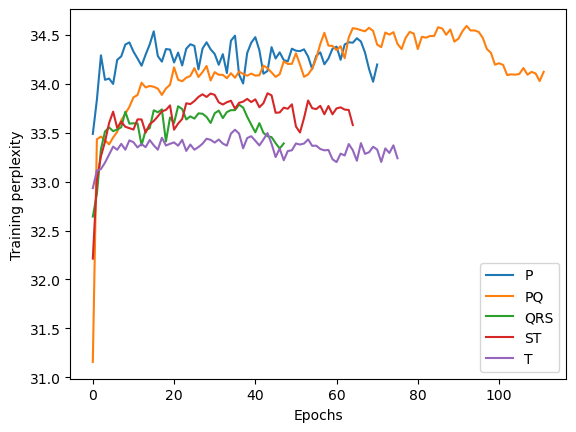

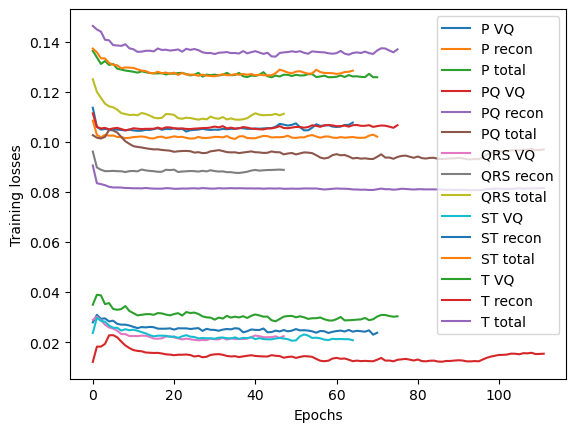

In [6]:
# Training results

regex = r".*training_outputs_([A-Za-z]+)\.npz"
train_vq_loss: dict[str, list] = {}
train_recon_loss: dict[str, list] = {}
train_loss: dict[str, list] = {}
for prefix_out in prefixes_out:
    match = re.search(regex, prefix_out)
    segment  = match.group(1)
    with s3_fs.open(f"s3://{bucket_out}/{prefix_out}", "rb") as s3_file:
        # Load the compressed data archive
        with np.load(s3_file) as data:
            # List all available array keys in the .npz archive
            print("Segment filename:", prefix_out)
            print("Segment name: ", segment)
            print("Available arrays:", data.files)
            print("Training VQ loss: ", data['train_loss'] - data['train_recon_error'] )
            print("Training reconstruction loss: ", data["train_recon_error"])
            print("Training perplexity:", data['train_perplexity'])
            nlogs = len(data['train_perplexity'])
            plt.plot(range(nlogs), data['train_perplexity'], label=segment)
            train_vq_loss[segment] = data['train_loss'] - data['train_recon_error']
            train_recon_loss[segment] = data["train_recon_error"]
            train_loss[segment] = data['train_loss']
    plt.legend()
    plt.xlabel("Epochs")
    plt.ylabel('Training perplexity')

plt.figure()
for segment in train_loss.keys():
    plt.plot(train_vq_loss[segment], label=f"{segment} VQ")
    plt.plot(train_recon_loss[segment], label=f"{segment} recon")
    plt.plot(train_loss[segment], label=f"{segment} total")
    plt.legend()
    plt.xlabel("Epochs")
    plt.ylabel("Training losses")


Segment name:  P
Val VQ loss:  [0.05299564 0.04902273 0.05021196 0.05143654 0.05121726 0.0508311
 0.05237404 0.0511934  0.05126605 0.05040572 0.04892481 0.05155621
 0.05024952 0.04725119 0.04964994 0.0501518  0.04790962 0.04918259
 0.04972371 0.04885198 0.05010312 0.04860823 0.04946672 0.04850082
 0.04743793 0.04882358 0.04833349 0.05048204 0.04896729 0.0503764
 0.04816637 0.05000979 0.04859751 0.04757273 0.04966493 0.04934076
 0.04840098 0.04852181 0.0462382  0.04736378 0.04664265 0.04712566
 0.04727777 0.04805938 0.0487959  0.04645678 0.04650865 0.04692623
 0.04780897 0.05007705 0.04858123 0.04867253 0.04841746 0.04860593
 0.04788334 0.04768612 0.04904496 0.04799419 0.04748983 0.04885485
 0.04997024 0.04749381 0.04742398 0.04770397 0.04686392 0.0477733
 0.04995875 0.05054989 0.04618345 0.04617172 0.04778113]
Val reconstruction loss:  [0.12003606 0.1200955  0.11732826 0.1155628  0.1137575  0.11507136
 0.1118564  0.11409167 0.11201173 0.11198442 0.11445668 0.11079512
 0.1116101  0.1094

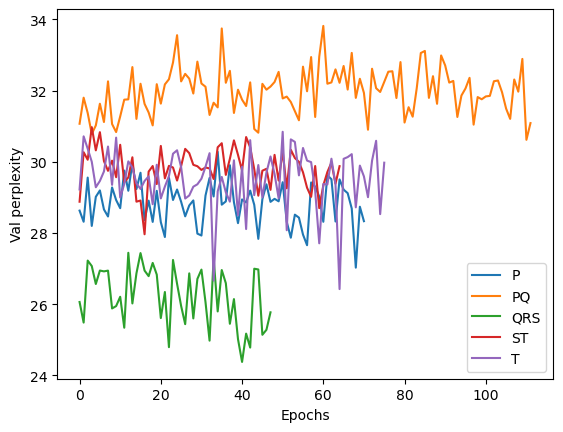

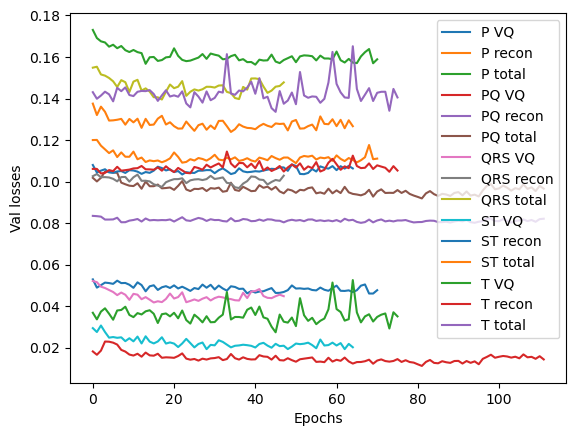

In [7]:
# Validation results

val_vq_loss: dict[str, list] = {}
val_recon_loss: dict[str, list] = {}
val_loss: dict[str, list] = {}
for prefix_out in prefixes_out:
    match = re.search(regex, prefix_out)
    segment  = match.group(1)
    with s3_fs.open(f"s3://{bucket_out}/{prefix_out}", "rb") as s3_file:
        # Load the compressed data archive
        with np.load(s3_file) as data:
            # List data in the .npz archive
            print("Segment name: ", segment)
            print("Val VQ loss: ", data['val_loss'] - data['val_recon_error'] )
            print("Val reconstruction loss: ", data["val_recon_error"])
            print("Val perplexity:", data['val_perplexity'])
            nlogs = len(data['val_perplexity'])
            plt.plot(range(nlogs), data['val_perplexity'], label=segment)
            val_vq_loss[segment] = data['val_loss'] - data['val_recon_error']
            val_recon_loss[segment] = data["val_recon_error"]
            val_loss[segment] = data['val_loss']
    plt.legend()
    plt.xlabel("Epochs")
    plt.ylabel('Val perplexity')

plt.figure()
for segment in val_loss.keys():
    plt.plot(val_vq_loss[segment], label=f"{segment} VQ")
    plt.plot(val_recon_loss[segment], label=f"{segment} recon")
    plt.plot(val_loss[segment], label=f"{segment} total")
    plt.legend()
    plt.xlabel("Epochs")
    plt.ylabel("Val losses")


In [8]:
# Test results

for prefix_out in prefixes_out:
    match = re.search(regex, prefix_out)
    segment  = match.group(1)
    with s3_fs.open(f"s3://{bucket_out}/{prefix_out}", "rb") as s3_file:
        # Load the compressed data archive
        with np.load(s3_file) as data:
            # List data in the .npz archive
            print("Segment name: ", segment)
            print("Test VQ loss: ", data['test_loss'] - data['test_recon_error'] )
            print("Test reconstruction loss: ", data["test_recon_error"])
            print("Test perplexity:", data['test_perplexity'])
            

Segment name:  P
Test VQ loss:  [0.02342433]
Test reconstruction loss:  [0.10267335]
Test perplexity: [30.10261223]
Segment name:  PQ
Test VQ loss:  [0.01141257]
Test reconstruction loss:  [0.08199618]
Test perplexity: [33.24884503]
Segment name:  QRS
Test VQ loss:  [0.01999166]
Test reconstruction loss:  [0.09009622]
Test perplexity: [27.78813657]
Segment name:  ST
Test VQ loss:  [0.02032869]
Test reconstruction loss:  [0.1032908]
Test perplexity: [30.3122071]
Segment name:  T
Test VQ loss:  [0.02799385]
Test reconstruction loss:  [0.10481727]
Test perplexity: [28.18658553]
